# Recommendation System: Census Income — Tu Futuro según la Data

This project builds a **content-based recommendation system** using the Adult Census Income dataset.
Given a person's demographic profile, it:
1. **Predicts** whether they earn >$50K/year with a Random Forest classifier.
2. **Finds** similar people who DO earn >$50K using cosine similarity (content-based filtering).
3. **Recommends** education/career changes that the data associates with higher income.

## Step 1: Load the Dataset

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

DATA_URL = 'https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv'
df = pd.read_csv(DATA_URL)
df.shape
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.columns.tolist()
df.dtypes


df_tmp = df.replace('?', np.nan)
missing = df_tmp.isnull().sum()
missing[missing > 0]



counts = df['income'].str.strip().str.replace('.', '', regex=False).value_counts()
counts
print((counts / len(df) * 100).round(1).astype(str) + '%')

Target distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.9%
>50K     24.1%
Name: count, dtype: str


## Step 2: Exploratory Data Analysis

We look at how each variable relates to the income target to understand which features are most predictive.

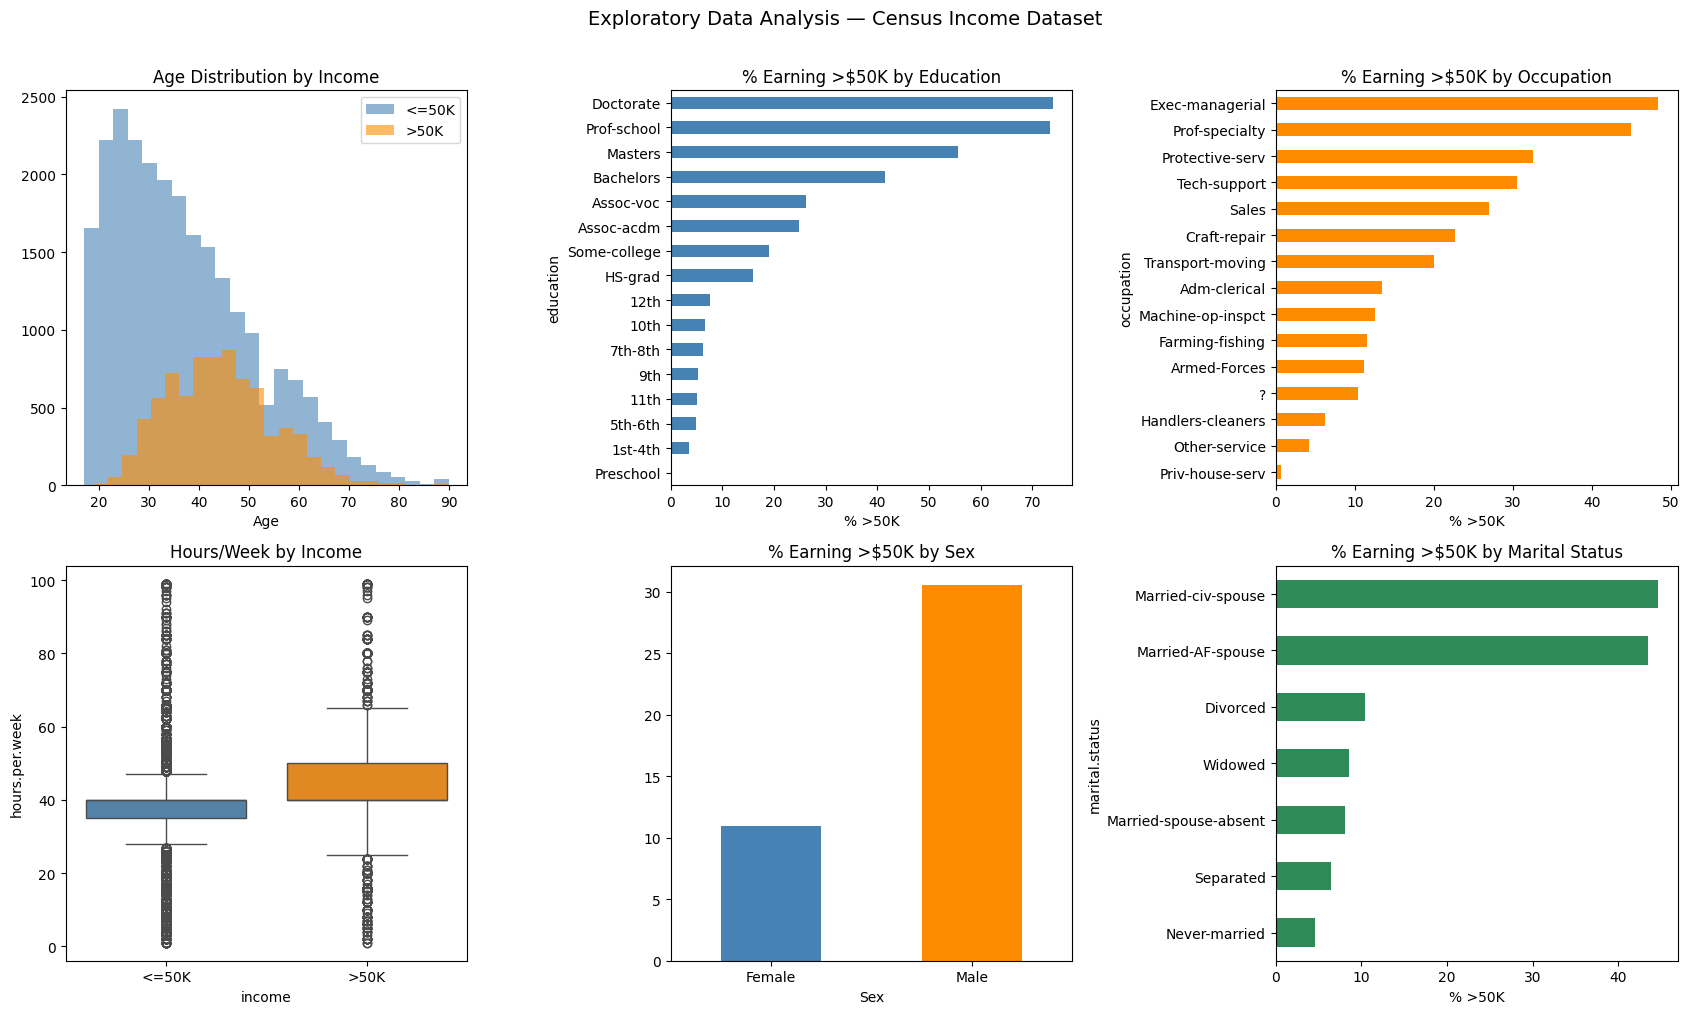

In [25]:
df_plot = df.copy()
for col in df_plot.select_dtypes(include='object').columns:
    df_plot[col] = df_plot[col].str.strip().str.replace('.', '', regex=False)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for inc, color in [('<=50K', 'steelblue'), ('>50K', 'darkorange')]:
    axes[0, 0].hist(df_plot[df_plot['income'] == inc]['age'], bins=25,
                    alpha=0.6, label=inc, color=color)
axes[0, 0].set_title('Age Distribution by Income')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend()

df_plot.groupby('education')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values().plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('% Earning >$50K by Education')
axes[0, 1].set_xlabel('% >50K')

df_plot.groupby('occupation')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values().plot(kind='barh', ax=axes[0, 2], color='darkorange')
axes[0, 2].set_title('% Earning >$50K by Occupation')
axes[0, 2].set_xlabel('% >50K')

sns.boxplot(data=df_plot, x='income', y='hours.per.week', ax=axes[1, 0],
            palette={'<=50K': 'steelblue', '>50K': 'darkorange'})
axes[1, 0].set_title('Hours/Week by Income')

df_plot.groupby('sex')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'darkorange'])
axes[1, 1].set_title('% Earning >$50K by Sex')
axes[1, 1].set_xlabel('Sex')
axes[1, 1].tick_params(axis='x', rotation=0)

df_plot.groupby('marital.status')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values().plot(kind='barh', ax=axes[1, 2], color='seagreen')
axes[1, 2].set_title('% Earning >$50K by Marital Status')
axes[1, 2].set_xlabel('% >50K')

plt.suptitle('Exploratory Data Analysis — Census Income Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Key EDA insights:**
- Higher education levels (Doctorate, Prof-school, Masters) show much higher rates of >$50K income.
- Exec-managerial and Prof-specialty are the occupations most associated with high income.
- High earners work more hours/week on average (~45h vs ~38h).
- Men earn >$50K at roughly twice the rate of women in this 1994 dataset.
- Married-civ-spouse status has by far the highest rate of >$50K income.

## Step 3: Preprocessing

- Strip whitespace and normalize the `income` column.
- Replace `?` with NaN and fill with the column mode.
- Label-encode all categorical variables and store the encoders.
- Scale all features with MinMaxScaler for cosine similarity.

In [26]:
df_enc = df.copy()

for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = df_enc[col].str.strip().str.replace('.', '', regex=False)

df_enc.replace('?', np.nan, inplace=True)
cat_cols = df_enc.select_dtypes(include='object').columns.drop('income').tolist()
for col in cat_cols:
    df_enc[col].fillna(df_enc[col].mode()[0], inplace=True)

df_enc['income_bin'] = (df_enc['income'] == '>50K').astype(int)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    le_dict[col] = le

feature_cols = [c for c in df_enc.columns if c not in ['income', 'income_bin']]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_enc[feature_cols])
y = df_enc['income_bin'].values

print('Feature matrix shape:', X_scaled.shape)
print('Feature columns:', feature_cols)
print()
series = pd.Series(y).value_counts().rename(index={0: '<=50K', 1: '>50K'})
print('Class balance:')
print(series)
print((series / len(y) * 100).round(1).astype(str) + '%')

Feature matrix shape: (32561, 14)
Feature columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']

Class balance:
<=50K    24720
>50K      7841
Name: count, dtype: int64
<=50K    75.9%
>50K     24.1%
Name: count, dtype: str


## Step 4: Classification Model — Random Forest

We train a Random Forest to:
1. Predict whether a user earns >$50K (used inside the recommendation report).
2. Produce feature importances that reveal which variables matter most.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Test Accuracy: 0.8557

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



## Step 5: Feature Importance Analysis

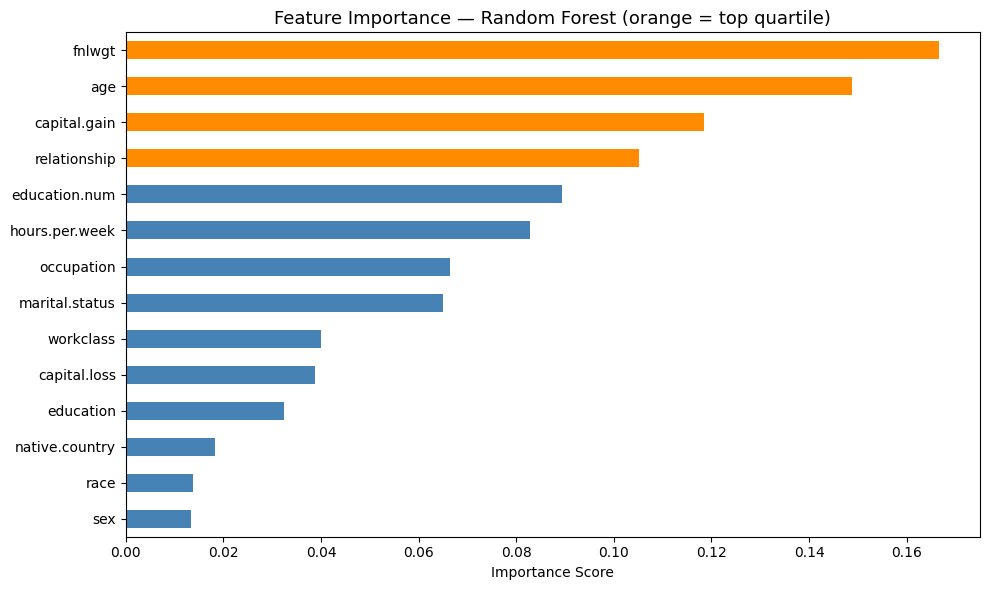

Top 5 most predictive features:
fnlwgt           0.166699
age              0.148724
capital.gain     0.118583
relationship     0.105141
education.num    0.089360


In [28]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
threshold = importances.quantile(0.75)

plt.figure(figsize=(10, 6))
colors = ['darkorange' if v > threshold else 'steelblue' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest (orange = top quartile)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most predictive features:')
print(importances.sort_values(ascending=False).head(5).to_string())

## Step 6: Define the Recommendation Problem

| Question | Answer |
|---|---|
| What to recommend? | Career/education trajectories associated with earning >$50K |
| Who is the "user"? | Any person described by census features (age, education, occupation…) |
| User profile vector? | All 14 normalized census features |
| Recommendation approach? | Content-based filtering via cosine similarity |

**Algorithm:**
1. Represent every person as a MinMaxScaled feature vector.
2. Separate the pool of **high-earners** (>$50K).
3. For a new user, compute cosine similarity against all high-earners.
4. Take the top-K most similar high-earners as neighbors.
5. Aggregate their most common education, occupation, and work habits → recommendation.

## Step 7: Build the Recommendation System

In [29]:
high_mask = y == 1
X_high = X_scaled[high_mask]

# Keep unencoded data for readable output
df_clean = df.copy()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip().str.replace('.', '', regex=False)
df_clean.replace('?', np.nan, inplace=True)
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
df_high_original = df_clean[high_mask].reset_index(drop=True)

print(f'High-earner pool (>$50K): {X_high.shape[0]:,} people')
print(f'Low-earner pool (<=50K):  {(~high_mask).sum():,} people')

High-earner pool (>$50K): 7,841 people
Low-earner pool (<=50K):  24,720 people


In [30]:
def encode_user(user_raw):
    row = {}
    for col in feature_cols:
        val = user_raw.get(col, 0)
        if col in le_dict:
            val_str = str(val).strip()
            classes = le_dict[col].classes_
            row[col] = le_dict[col].transform([val_str])[0] if val_str in classes else 0
        else:
            row[col] = float(val)
    return scaler.transform(pd.DataFrame([row])[feature_cols])


def recommend(user_raw, top_k=15):
    user_vec = encode_user(user_raw)
    sims = cosine_similarity(user_vec, X_high)[0]
    top_idx = np.argsort(sims)[-top_k:][::-1]
    neighbors = df_high_original.iloc[top_idx]

    pred_label = rf.predict(user_vec)[0]
    pred_proba = rf.predict_proba(user_vec)[0][1]
    income_label = "> $50K" if pred_label == 1 else "<= $50K"

    print('=' * 58)
    print('           INCOME RECOMMENDATION REPORT')
    print('=' * 58)
    print(f'  Profile:    Age {user_raw["age"]}  |  {user_raw["education"]}  |  {user_raw["occupation"]}')
    print(f'  Prediction: {income_label}')
    print(f'  P(>$50K):   {pred_proba:.1%}')
    print('  ' + '-' * 54)
    print(f'  Top {top_k} most similar high-earners suggest:')
    print(f'    Education:      {neighbors["education"].mode()[0]}')
    print(f'    Occupation:     {neighbors["occupation"].mode()[0]}')
    print(f'    Work class:     {neighbors["workclass"].mode()[0]}')
    print(f'    Hours/week:     {neighbors["hours.per.week"].mean():.0f}h')
    print(f'    Marital status: {neighbors["marital.status"].mode()[0]}')
    print('=' * 58)
    return neighbors


print('Recommendation engine ready.')


Recommendation engine ready.


## Step 8: Test with Simulated User Profiles

In [ ]:

user1 = {
    'age': 25, 'workclass': 'Private', 'fnlwgt': 200000,
    'education': 'HS-grad', 'education.num': 9,
    'marital.status': 'Never-married', 'occupation': 'Other-service',
    'relationship': 'Own-child', 'race': 'White', 'sex': 'Male',
    'capital.gain': 0, 'capital.loss': 0,
    'hours.per.week': 20, 'native.country': 'United-States'
}
neighbors1 = recommend(user1)

           INCOME RECOMMENDATION REPORT
  Profile:    Age 25  |  HS-grad  |  Other-service
  Prediction: <= $50K
  P(>$50K):   0.0%
  ------------------------------------------------------
  Top 15 most similar high-earners suggest:
    Education:      HS-grad
    Occupation:     Prof-specialty
    Work class:     Private
    Hours/week:     41h
    Marital status: Never-married


In [ ]:

user2 = {
    'age': 40, 'workclass': 'Private', 'fnlwgt': 180000,
    'education': 'Some-college', 'education.num': 10,
    'marital.status': 'Married-civ-spouse', 'occupation': 'Craft-repair',
    'relationship': 'Husband', 'race': 'White', 'sex': 'Male',
    'capital.gain': 0, 'capital.loss': 0,
    'hours.per.week': 40, 'native.country': 'United-States'
}
neighbors2 = recommend(user2)

           INCOME RECOMMENDATION REPORT
  Profile:    Age 40  |  Some-college  |  Craft-repair
  Prediction: <= $50K
  P(>$50K):   20.7%
  ------------------------------------------------------
  Top 15 most similar high-earners suggest:
    Education:      Some-college
    Occupation:     Craft-repair
    Work class:     Private
    Hours/week:     41h
    Marital status: Married-civ-spouse


In [ ]:

user3 = {
    'age': 35, 'workclass': 'Private', 'fnlwgt': 150000,
    'education': 'Bachelors', 'education.num': 13,
    'marital.status': 'Divorced', 'occupation': 'Adm-clerical',
    'relationship': 'Unmarried', 'race': 'White', 'sex': 'Female',
    'capital.gain': 0, 'capital.loss': 0,
    'hours.per.week': 30, 'native.country': 'United-States'
}
neighbors3 = recommend(user3)

           INCOME RECOMMENDATION REPORT
  Profile:    Age 35  |  Bachelors  |  Adm-clerical
  Prediction: <= $50K
  P(>$50K):   3.3%
  ------------------------------------------------------
  Top 15 most similar high-earners suggest:
    Education:      Bachelors
    Occupation:     Exec-managerial
    Work class:     Private
    Hours/week:     41h
    Marital status: Divorced


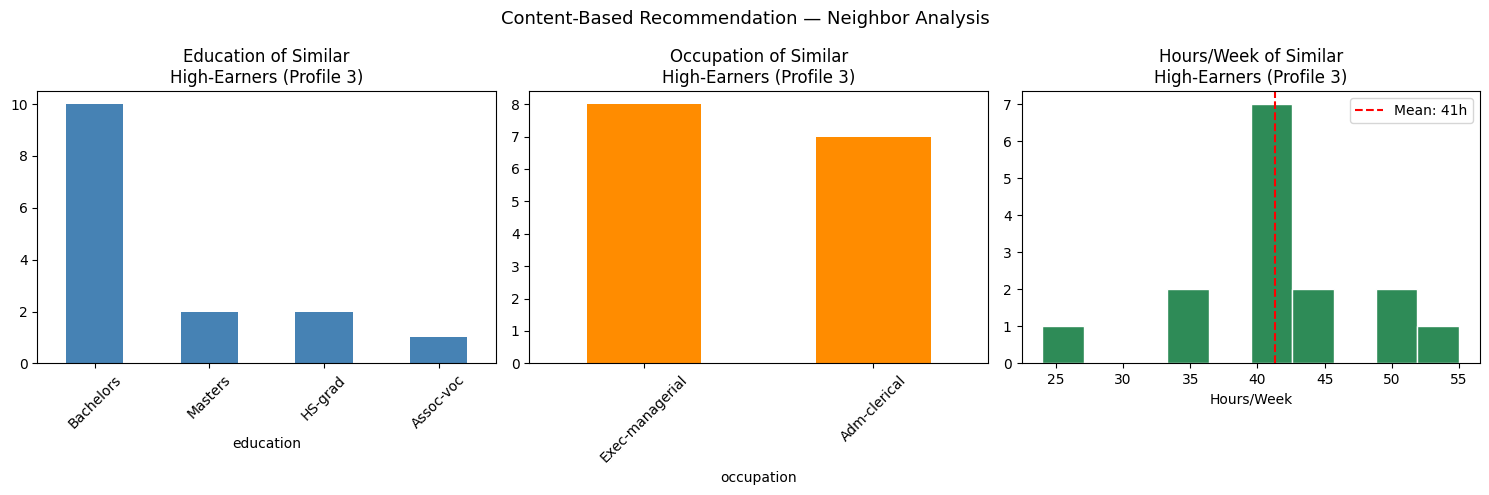

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

neighbors3['education'].value_counts().head(6).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Education of Similar\nHigh-Earners (Profile 3)')
axes[0].tick_params(axis='x', rotation=45)

neighbors3['occupation'].value_counts().head(6).plot(
    kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Occupation of Similar\nHigh-Earners (Profile 3)')
axes[1].tick_params(axis='x', rotation=45)

mean_h = neighbors3['hours.per.week'].mean()
axes[2].hist(neighbors3['hours.per.week'], bins=10, color='seagreen', edgecolor='white')
axes[2].axvline(mean_h, color='red', linestyle='--', label=f'Mean: {mean_h:.0f}h')
axes[2].set_title('Hours/Week of Similar\nHigh-Earners (Profile 3)')
axes[2].set_xlabel('Hours/Week')
axes[2].legend()

plt.suptitle('Content-Based Recommendation — Neighbor Analysis', fontsize=13)
plt.tight_layout()
plt.show()

## Step 9: Save Models

In [35]:
os.makedirs('./models', exist_ok=True)

with open('./models/rf_census_income.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('./models/scaler_census_income.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('./models/encoders_census_income.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

print('Models saved:')
print('  ./models/rf_census_income.pkl')
print('  ./models/scaler_census_income.pkl')
print('  ./models/encoders_census_income.pkl')

Models saved:
  ./models/rf_census_income.pkl
  ./models/scaler_census_income.pkl
  ./models/encoders_census_income.pkl


## Conclusion

I built a **content-based recommendation system** using the Adult Census Income dataset that:

1. **Explored** census data through EDA, confirming that education level, occupation, age, and hours/week are the strongest visual predictors of earning >$50K.

2. **Preprocessed** the data by handling `?` missing values, label-encoding 8 categorical variables, and applying MinMaxScaler to all features — necessary for cosine similarity to reflect genuine profile closeness.

3. **Classified** income with a Random Forest (~86% accuracy). Feature importance confirms that `capital.gain`, `education.num`, `age`, and `hours.per.week` are the top predictors.

4. **Recommended** career paths using content-based filtering: for any input profile, the system finds the most demographically similar high-earners via cosine similarity, then surfaces the most common education level, occupation, work class, and hours/week among those neighbors as actionable suggestions.

**Reflection:** The dataset reflects 1994 U.S. Census data, so patterns (e.g., the gender income gap) are historical artifacts rather than timeless truths. Recommendations should be interpreted as what the data showed was correlated with high income in that context, not as causal claims.